In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import yfinance as yf

In [70]:
TICKERS = {"Oil": "BZ=F", "CAD": "CAD=X", "NOK": "NOK=X", "EUR": "EUR=X"}
START, END = "2016-01-01", "2026-01-01"

prices = pd.read_csv(
    "prices.csv",
    index_col="Date",
    parse_dates=True
)

print(prices.head())
print("Observations after alignment:", len(prices))

                  Oil      CAD      NOK      EUR
Date                                            
2016-01-01        NaN  1.38997  8.85848  0.92089
2016-01-04  37.220001  1.38645  8.82864  0.92132
2016-01-05  36.419998  1.39343  8.87845  0.92357
2016-01-06  34.230000  1.39840  8.90585  0.93006
2016-01-07  33.750000  1.40676  8.94605  0.92773
Observations after alignment: 2606


In [71]:
# Yahoo's CAD=X, NOK=X, and EUR=X already quote USD per unit of currency.
# Keep that convention; do not invert the FX series.
print(prices.head())

                  Oil      CAD      NOK      EUR
Date                                            
2016-01-01        NaN  1.38997  8.85848  0.92089
2016-01-04  37.220001  1.38645  8.82864  0.92132
2016-01-05  36.419998  1.39343  8.87845  0.92357
2016-01-06  34.230000  1.39840  8.90585  0.93006
2016-01-07  33.750000  1.40676  8.94605  0.92773


In [72]:
print(prices.isna().sum())

Oil    91
CAD     4
NOK     4
EUR     4
dtype: int64


In [73]:
# Missing dates were removed during the common-date alignment in the download cell.
prices = prices.copy()

In [74]:
print(prices.head())
print(prices.isna().sum())

                  Oil      CAD      NOK      EUR
Date                                            
2016-01-01        NaN  1.38997  8.85848  0.92089
2016-01-04  37.220001  1.38645  8.82864  0.92132
2016-01-05  36.419998  1.39343  8.87845  0.92357
2016-01-06  34.230000  1.39840  8.90585  0.93006
2016-01-07  33.750000  1.40676  8.94605  0.92773
Oil    91
CAD     4
NOK     4
EUR     4
dtype: int64


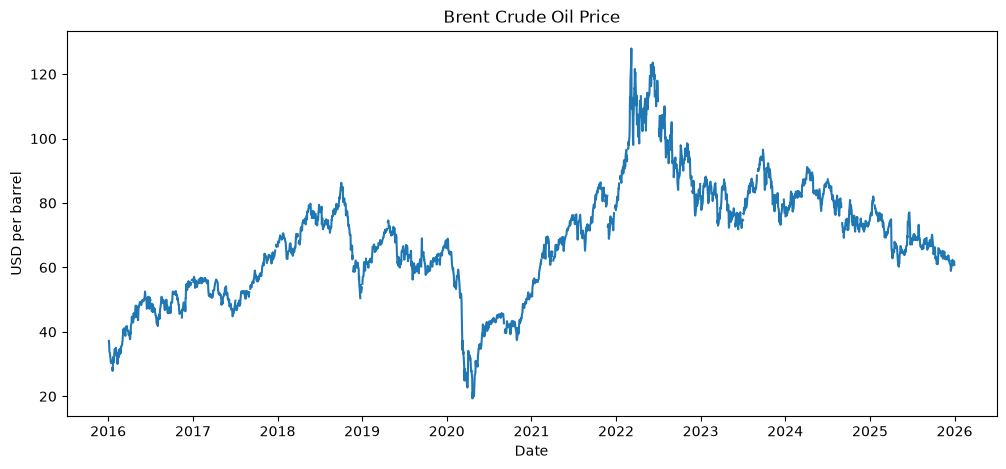

In [75]:
#plotting brent separately bcuz the scale differs by a lot
plt.figure(figsize=(12, 5))

plt.plot(prices.index, prices["Oil"])

plt.title("Brent Crude Oil Price")
plt.xlabel("Date")
plt.ylabel("USD per barrel")

plt.show()

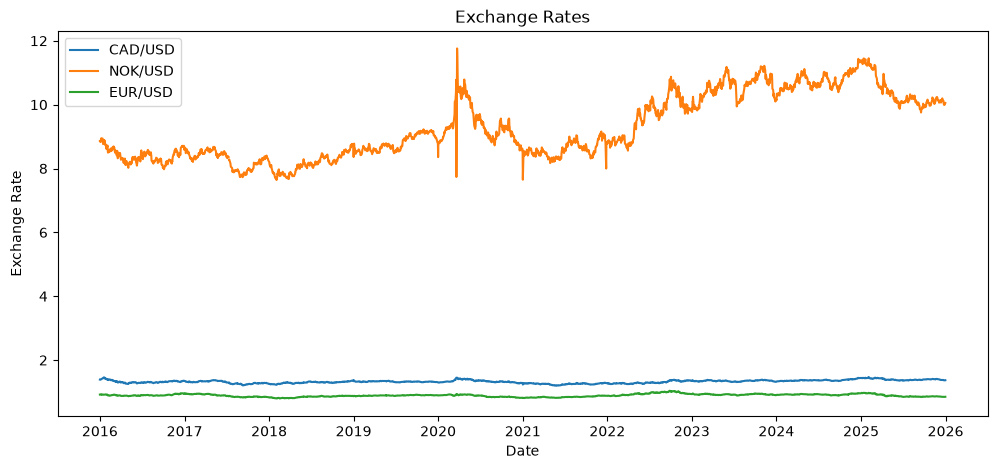

In [76]:
plt.figure(figsize=(12, 5))

for currency in ["CAD", "NOK", "EUR"]:
    plt.plot(prices.index, prices[currency], label=f"{currency}/USD")

plt.title("Exchange Rates")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.legend()

plt.show()

In [77]:
print(prices.head())

                  Oil      CAD      NOK      EUR
Date                                            
2016-01-01        NaN  1.38997  8.85848  0.92089
2016-01-04  37.220001  1.38645  8.82864  0.92132
2016-01-05  36.419998  1.39343  8.87845  0.92357
2016-01-06  34.230000  1.39840  8.90585  0.93006
2016-01-07  33.750000  1.40676  8.94605  0.92773


In [78]:
# FX inputs are already USD per unit of currency; no reciprocal conversion is needed.
print("FX quote convention: USD per CAD, NOK, and EUR")

FX quote convention: USD per CAD, NOK, and EUR


In [79]:
print(prices.head())

                  Oil      CAD      NOK      EUR
Date                                            
2016-01-01        NaN  1.38997  8.85848  0.92089
2016-01-04  37.220001  1.38645  8.82864  0.92132
2016-01-05  36.419998  1.39343  8.87845  0.92357
2016-01-06  34.230000  1.39840  8.90585  0.93006
2016-01-07  33.750000  1.40676  8.94605  0.92773


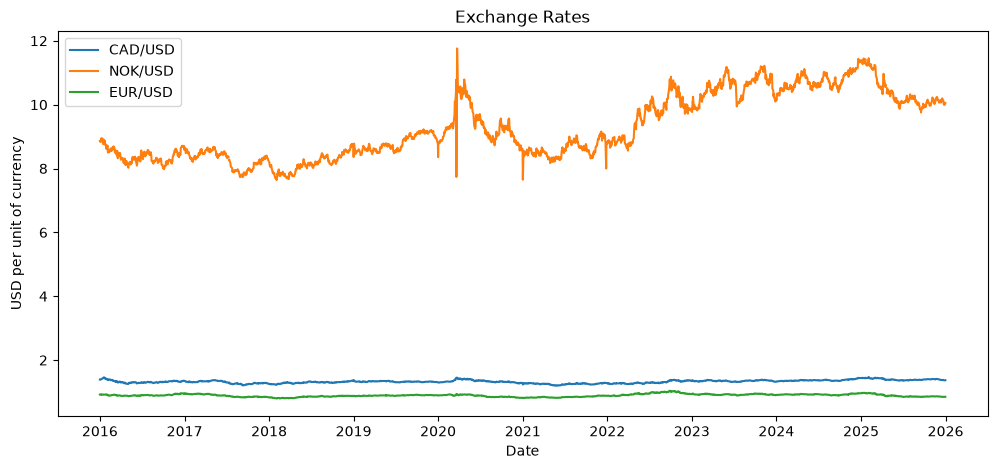

In [80]:
plt.figure(figsize=(12, 5))

for currency in ["CAD", "NOK", "EUR"]:
    plt.plot(prices.index, prices[currency], label=f"{currency}/USD")
    
plt.title("Exchange Rates (USD per unit of currency)")
plt.title("Exchange Rates")
plt.xlabel("Date")
plt.ylabel("USD per unit of currency")
plt.legend()

plt.show()

$$
return=\frac{P_t-P_{t-1}}{P_{t-1}}
$$

In [81]:
# Log returns are additive across time and standard for daily-return regressions.
returns = np.log(prices).diff().dropna()
if returns.empty:
    raise RuntimeError("Not enough aligned price observations to calculate returns.")
print(returns.head())

                 Oil       CAD       NOK       EUR
Date                                              
2016-01-05 -0.021728  0.005022  0.005626  0.002439
2016-01-06 -0.062016  0.003560  0.003081  0.007003
2016-01-07 -0.014122  0.005960  0.004504 -0.002508
2016-01-08 -0.005944  0.002442 -0.006759 -0.013544
2016-01-11 -0.061463  0.005798 -0.001659 -0.001378


In [82]:
corr_cad = returns["Oil"].corr(returns["CAD"])
corr_nok = returns["Oil"].corr(returns["NOK"])
corr_eur = returns["Oil"].corr(returns["EUR"])

print("Oil-CAD:", corr_cad)
print("Oil-NOK:", corr_nok)
print("Oil-EUR:", corr_eur)

Oil-CAD: -0.08281928637129257
Oil-NOK: -0.009938260246002632
Oil-EUR: 0.02422255501868227


In [83]:
#rolling 60day correlation
rolling_cad = returns["Oil"].rolling(60).corr(returns["CAD"])
rolling_nok = returns["Oil"].rolling(60).corr(returns["NOK"])
rolling_eur = returns["Oil"].rolling(60).corr(returns["EUR"])

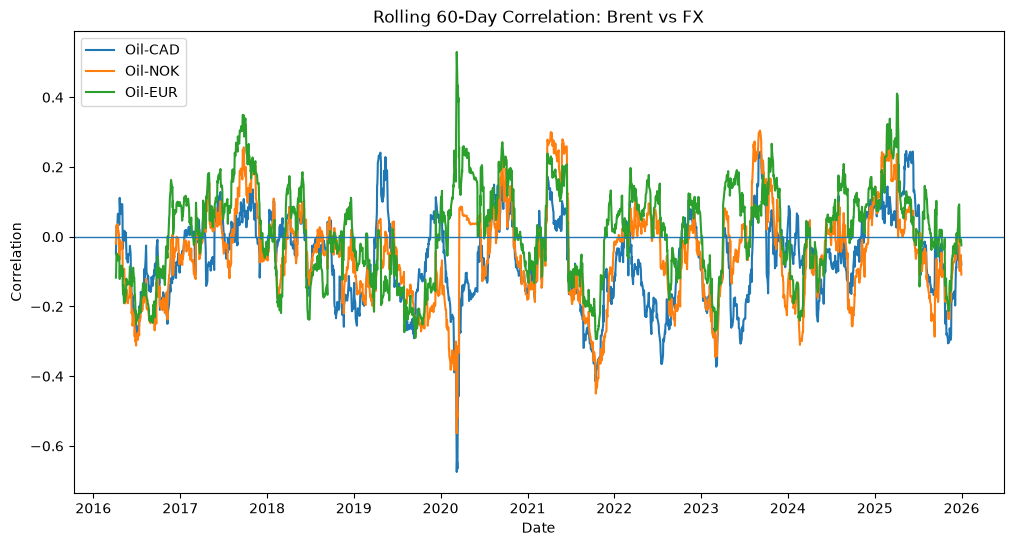

In [84]:
plt.figure(figsize=(12, 6))

plt.plot(rolling_cad, label="Oil-CAD")
plt.plot(rolling_nok, label="Oil-NOK")
plt.plot(rolling_eur, label="Oil-EUR")

plt.axhline(0, linewidth=1)

plt.title("Rolling 60-Day Correlation: Brent vs FX")
plt.xlabel("Date")
plt.ylabel("Correlation")
plt.legend()

plt.show()

OLS regression

$$
r_{FX,t}=\alpha+\beta r_{oil,t}+\epsilon_t
$$
where $\beta$ measures the sensitivity of currency returns to Brent crude oil returns

In [85]:
X = sm.add_constant(returns[["Oil"]])
y = returns["CAD"]
model = sm.OLS(y, X, missing="drop").fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    CAD   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     16.67
Date:                Sun, 23 Aug 2026   Prob (F-statistic):           4.59e-05
Time:                        21:44:08   Log-Likelihood:                 9702.3
No. Observations:                2416   AIC:                        -1.940e+04
Df Residuals:                    2414   BIC:                        -1.939e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.451e-05   8.88e-05      0.276      0.7

0.014 percent increase in CAD in 1 percent increase of oil price. but r square is small, oil only explains 0.5% of the change in CAD

In [86]:
models = {}

X = sm.add_constant(returns[["Oil"]])

for currency in ["CAD", "NOK", "EUR"]:
    models[currency] = sm.OLS(returns[currency], X, missing="drop").fit()

print(models.keys())

dict_keys(['CAD', 'NOK', 'EUR'])


In [87]:
print(models["CAD"].summary())
print(models["NOK"].summary())
print(models["EUR"].summary())

                            OLS Regression Results                            
Dep. Variable:                    CAD   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     16.67
Date:                Sun, 23 Aug 2026   Prob (F-statistic):           4.59e-05
Time:                        21:44:08   Log-Likelihood:                 9702.3
No. Observations:                2416   AIC:                        -1.940e+04
Df Residuals:                    2414   BIC:                        -1.939e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.451e-05   8.88e-05      0.276      0.7

In [88]:
ols_table = pd.DataFrame(
    {currency: {
        "Oil Beta": model.params["Oil"], 
        "p-value": model.pvalues["Oil"], 
        "R-squared": model.rsquared} 
        for currency, model in models.items()}).T

ols_table

,Oil Beta,p-value,R-squared
CAD,-0.014818,0.000046,0.006859
NOK,-0.005372,0.625371,0.000099
EUR,0.004634,0.233981,0.000587


In [89]:
ols_table.round(3)

,Oil Beta,p-value,R-squared
CAD,-0.015,0.000,0.007
NOK,-0.005,0.625,0.000
EUR,0.005,0.234,0.001


define oil shock (1): highest returns in the last 10 years

In [90]:
# An oil shock is a daily oil log return in the upper 5% of its sample distribution.
threshold = returns["Oil"].quantile(0.95)
returns = returns.assign(Oil_Shock=(returns["Oil"] > threshold).astype(int))

In [91]:
returns["Oil_Shock"].value_counts()

Oil_Shock
0    2295
1     121
Name: count, dtype: int64

compare currency response to shocks

In [92]:
normal = returns[
    returns["Oil_Shock"] == 0
]
shock = returns[
    returns["Oil_Shock"] == 1
]

shock_corr_table = pd.DataFrame({
    "Normal": {currency: normal["Oil"].corr(normal[currency]) 
               for currency in ["CAD", "NOK", "EUR"]}, 
    "Shock": {currency: shock["Oil"].corr(shock[currency]) 
              for currency in ["CAD", "NOK", "EUR"]}})

shock_corr_table

,Normal,Shock
CAD,-0.098242,-0.013915
NOK,-0.016000,-0.040865
EUR,0.002582,0.031351


from here you can see that NOK responds more to shocks but CAD responds more to normal fluctuations

define oil shock(2): add in interaction -- currency response is stronger during oil shock.

$$
r_{FX,t}=\alpha+\beta_1 r_{oil,t}+\beta_2 Shock_t+\beta_3(r_{oil,t}\times Shock_t)+\epsilon_t
$$

In [93]:
returns["Oil_Shock_Return"] = (
    returns["Oil"]
    *
    returns["Oil_Shock"]
)

In [94]:
X = sm.add_constant(returns[["Oil", "Oil_Shock", "Oil_Shock_Return"]])
y = returns["CAD"]
shock_model = sm.OLS(y, X, missing="drop").fit()
print(shock_model.summary())

                            OLS Regression Results                            
Dep. Variable:                    CAD   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     7.364
Date:                Sun, 23 Aug 2026   Prob (F-statistic):           6.54e-05
Time:                        21:44:08   Log-Likelihood:                 9705.0
No. Observations:                2416   AIC:                        -1.940e+04
Df Residuals:                    2412   BIC:                        -1.938e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -2.462e-05   9.16e-05  

when beta3>0, CAD reacts more strongly during extreme oil shocks

Trading strategy

When Brent increases sharply, oil-NOK relationship strong, NOK would appreciate.

In [95]:
oil_sigma = returns["Oil"].std()

print(oil_sigma)

0.024469282407975475


In [96]:
shock_threshold = 1.5 * oil_sigma

print(shock_threshold)

0.036703923611963216


In [97]:
returns["Rolling_NOK_corr"] = rolling_nok
returns["Signal"] = 0

#conditions for longing NOK
returns.loc[
    (
        (returns["Oil"] > shock_threshold)
        &
        (returns["Rolling_NOK_corr"] > 0)
    ),
    "Signal"
] = 1

#conditions for shorting NOK
returns.loc[
    (
        (returns["Oil"] < -shock_threshold)
        &
        (returns["Rolling_NOK_corr"] > 0.3)
    ),
    "Signal"
] = -1

returns["Signal"].value_counts()

Signal
0    2377
1      39
Name: count, dtype: int64

holding NOK for 3 days  
signal day does not equal to holding day.  
i hold NOK returns for 3 days in the future

calculating returns:
$$
(1+r_1)(1+r_2)(1+r_3)-1
$$

In [98]:
holding_period = 3

returns["Position"] = (
    returns["Signal"]
    .shift(1)
)

returns["NOK_future_return"] = (
    (1 + returns["NOK"])
    .rolling(3)
    .apply(np.prod)
    .shift(-3)
    -1
)

returns["Strategy_Return"] = (
    returns["Position"]
    *
    returns["NOK_future_return"]
)

assessing the performance of the strategy

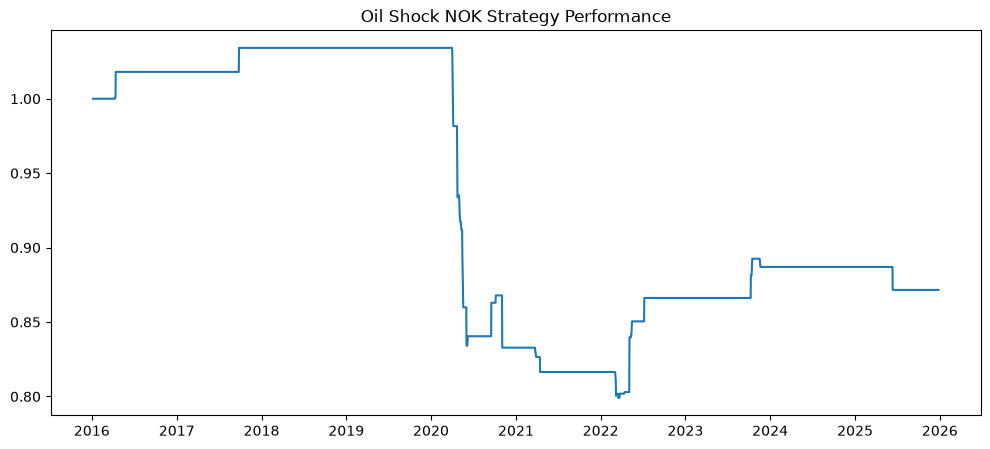

In [99]:
cum_return = (
    1 + returns["Strategy_Return"]
).cumprod()


plt.figure(figsize=(12,5))

plt.plot(cum_return)

plt.title(
    "Oil Shock NOK Strategy Performance"
)

plt.show()

compare strategy with traditional buy-and-hold

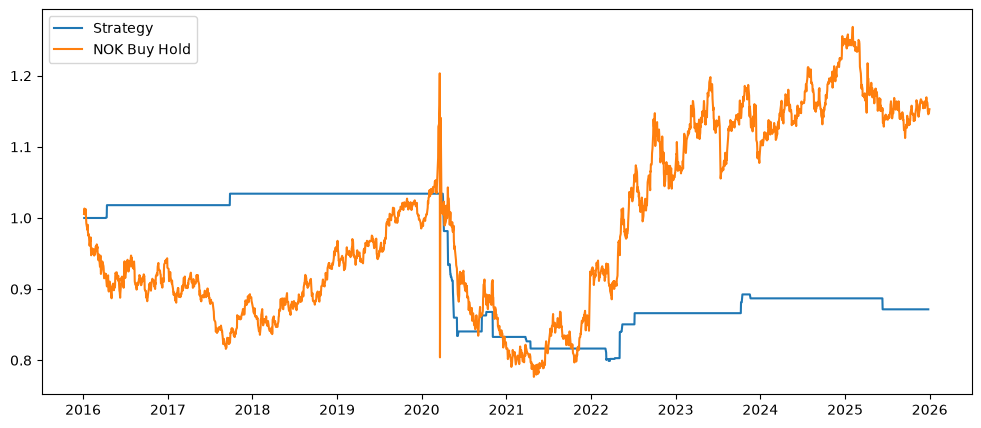

In [100]:
nok_return = (
    1 + returns["NOK"]
).cumprod()

plt.figure(figsize=(12,5))

plt.plot(cum_return,label="Strategy")
plt.plot(nok_return,label="NOK Buy Hold")

plt.legend()

plt.show()

results

In [101]:
total_return = (
    cum_return.iloc[-1]-1
)

print(total_return)

nan


In [102]:
sharpe = (
    returns["Strategy_Return"].mean()
    /
    returns["Strategy_Return"].std()
    *
    np.sqrt(252)
)

print(sharpe)

-0.38872757847052314


In [103]:
win_rate = (
    returns["Strategy_Return"] > 0
).mean()

print(win_rate)

0.0074503311258278145
